In [29]:
# @title
# @setup-db
%%bash
sqlite3 db.db <<EOF
-- 2. Creación de Tablas
CREATE TABLE Categorias (
    id_categoria INTEGER PRIMARY KEY AUTOINCREMENT,
    nombre VARCHAR(50) NOT NULL
);

CREATE TABLE Productos (
    id_producto  INTEGER PRIMARY KEY AUTOINCREMENT,
    nombre VARCHAR(100) NOT NULL,
    id_categoria INT,
    precio DECIMAL(10,2),
    stock INT,
    FOREIGN KEY (id_categoria) REFERENCES Categorias(id_categoria)
);

CREATE TABLE Ventas (
    id_venta  INTEGER PRIMARY KEY AUTOINCREMENT,
    id_producto INT,
    cantidad INT,
    fecha DATE,
    total_venta DECIMAL(10,2),
    FOREIGN KEY (id_producto) REFERENCES Productos(id_producto)
);

-- 3. Inserción de Datos
INSERT INTO Categorias (nombre) VALUES ('Electrónica'), ('Hogar'), ('Deportes');
INSERT INTO Productos (nombre, id_categoria, precio, stock) VALUES
('Laptop', 1, 1200.00, 15),
('Smartphone', 1, 800.00, 25),
('Cafetera', 2, 50.00, 10),
('Licuadora', 2, 40.00, 8),
('Balón Fútbol', 3, 25.00, 50),
('Pesas 5kg', 3, 30.00, 20);
INSERT INTO Ventas (id_producto, cantidad, fecha, total_venta) VALUES
(1, 2, '2024-05-10', 2400.00),
(2, 5, '2024-05-11', 4000.00),
(3, 1, '2024-05-12', 50.00),
(1, 1, '2024-05-13', 1200.00),
(5, 10, '2024-05-14', 250.00),
(6, 4, '2024-05-15', 120.00);
EOF

In [24]:
import sqlite3
import polars
import matplotlib.pyplot as plt
import seaborn as sns

producto,categoria,precio,stock
str,str,i64,i64
"""Laptop""","""Electrónica""",1200,15
"""Smartphone""","""Electrónica""",800,25
"""Cafetera""","""Hogar""",50,10
"""Licuadora""","""Hogar""",40,8
"""Balón Fútbol""","""Deportes""",25,50
"""Pesas 5kg""","""Deportes""",30,20


/tmp/ipykernel_887/74387955.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


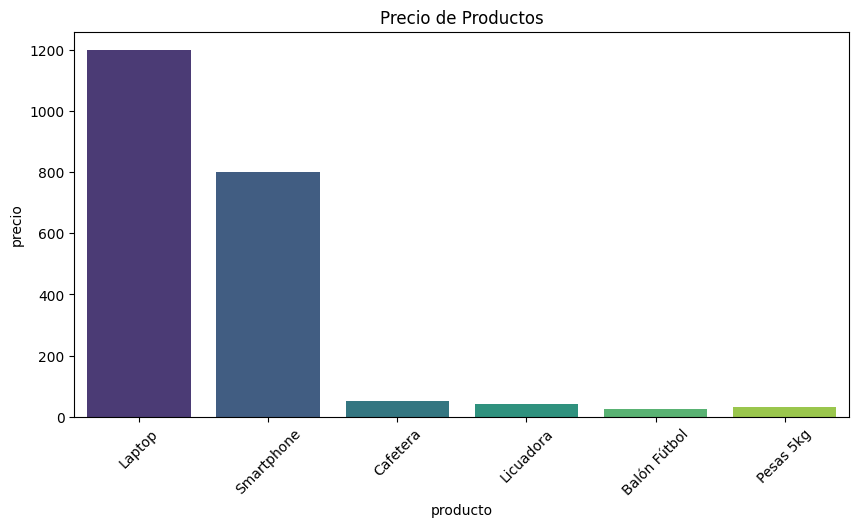

In [27]:
query = """
select
    p.nombre as producto,
    c.nombre as categoria,
    p.precio,
    p.stock
from Productos p
inner join categorias c on p.id_categoria = c.id_categoria
"""

with sqlite3.connect("db.db") as conn:
    df = polars.read_database(query=query, connection=conn)
    display(df)
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=df,
        x='producto',
        y='precio',
        palette='viridis'
    )

    plt.title("Precio de Productos")
    plt.xticks(rotation=45)
    plt.show()